# Test BERTScore



## Setup

### Pakete laden

In [1]:
import config

import time

import numpy as np
import pandas as pd

# Hugging-Face datasets
import datasets

import scipy.stats as stats

from util.bertscore import BERTScore
from util.px import PX

### Variablen+Funktionen

In [2]:
scorer = BERTScore()

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: google-bert/bert-large-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## BERTScore

BERTScore wurde ursprünglich für die automatisierte Evaluierung der Ausgaben von generativen Sprachmodellen, bspw. Übersetzungen, entwickelt. Ziel dabei war der Vergleich der Ähnlichkeit für relativ kurze Text-Sequenzen, Übersetzungen einzelner Beispiel-Sätze mit dazugehörigen Referenz-Übersetzungen.

Ausgehend von einem in $n$ Worte bzw. Token zerlegten Referenz-Satz $S=(w_1, w_2, \dots, w_n)$ und einen in $m$ Token zerlegten Kandidaten-Satz $\hat{S}=\hat{w}_1, \hat{w}_2, \dots, \hat{w}_m$, wobei jedes Wort $w_i$ aus einem definierten Vokabular $V$ stammt ($w_i \in V$), überführt das Modell (Abbildungsfunktion $f$) jedes Token $w_i$ in einen dichten, $d$-dimensionalen Vektorraum und erzeugt einen Embedding-Vektor $\mathbf{e}_i$.

$$f: V \rightarrow \mathbb{R}^d$$

$$\mathbf{e}_i = f(w_i) \quad \text{für } i = 1, 2, \dots, n$$

Das Ergebnis für den gesamten Text ist eine Matrix von Embedding-Vektoren.

$$E = (\mathbf{e}_1, \mathbf{e}_2, \mathbf{e}_3, \dots, \mathbf{e}_n)$$

$$\hat{E} = (\mathbf{\hat{e}}_1, \mathbf{\hat{e}}_2, \mathbf{\hat{e}}_3, \dots, \mathbf{\hat{e}}_n)$$

Mittels einer Matrix-Multiplikation der normierten Vektoren wird zwischen jedem Token des Kandidaten-Satz und des Referenz-Satz die Kosinus-Ähnlichkeit berechnet. Die daraus entstehende Matrix gibt an, wie nah sich die Wörter der beiden Texte in ihrer Bedeutung stehen. Anstatt nur gleiche Wörter zu zählen, sucht das Verfahren für jedes Wort im Kandidaten-Satz das semantisch ähnlichste Gegenstück im Referenztext und umgekehrt.

Das System berechnet die Kosinus-Ähnlichkeit zwischen jedem Token des Kandidatentextes und jedem Token des Referenztextes. Dadurch entsteht eine Matrix, die zeigt, wie nah sich alle Wörter in ihrer Bedeutung stehen. Aus den ermittelten Ähnlichkeiten werden drei statistische Maßeberechnet.

Precision (Präzision) $P$: Misst, wie viele Wörter des generierten Textes $\hat{S}$ eine Entsprechung im Referenztext $S$ haben.

$$\text{R}_{BERT}=\frac{1}{|e|} \sum_{e_i \in E} \max\limits_{\hat{e}_j \in \hat{E}} \mathbf{e}_i^T \mathbf{\hat{e}}_j$$

Recall (Rückgabe/Vollständigkeit) $R$: Misst, wie viele Wörter des Referenztextes $S$ im generierten Text $\hat{S}$ abgedeckt wurden.

$$\text{P}_{BERT}=\frac{1}{|\hat{e}|} \sum_{\hat{e}_j \in \hat{E}} \max\limits_{e_i \in E} \mathbf{e}_i^T \mathbf{\hat{e}}_j$$

F1-Score: Das harmonische Mittel zwischen Precision und Recall bildet den finalen BERTScore, der als einzelner Wert (zwischen 0 und 1) die Gesamtqualität widerspiegelt.

$$\text{F1}_{BERT}=2\frac{\text{P}_{BERT}\text{R}_{BERT}}{\text{P}_{BERT}+\text{R}_{BERT}}$$

### SemRel2024 Dataset

https://huggingface.co/datasets/SemRel/SemRel2024  
https://arxiv.org/pdf/2402.08638v5

Der SemRel2024-Datensatz beinhaltet eine Sammlung von insgesamt 8150 Satz-Paaren und dazugehörige Score-Werte, welche die Ähnlichkeit zwischen den Sätzen angeben. Für den Test werden 2600 Beobachtungen des Test-Sets verwendet.

In [3]:
dataset_semRel2024 = datasets.load_dataset("SemRel/SemRel2024", "eng")

In [12]:
#dataset_semRel2024

In [4]:
#sample = 500

# Dataset splitten, random samples für Test selektieren
#dataset_semRel2024_split = dataset_semRel2024['test'].train_test_split(test_size=sample / dataset_semRel2024['test'].shape[0], seed=42)

dataset_semRel2024_split = dataset_semRel2024['test']

In [5]:
# statistische Kennzahlen
dataset_semRel2024_split_test_label = np.array(dataset_semRel2024_split['label'])

print(f'mean: {dataset_semRel2024_split_test_label.mean()}')
print(f'min: {dataset_semRel2024_split_test_label.min()}')
print(f'max: {dataset_semRel2024_split_test_label.max()}')
print(f'median: {np.median(dataset_semRel2024_split_test_label)}')
print(f'std: {dataset_semRel2024_split_test_label.std()}')
print(f'var: {dataset_semRel2024_split_test_label.var()}')

mean: 0.5166153846153846
min: 0.12
max: 0.97
median: 0.48
std: 0.16995928854673878
var: 0.028886159763313612


### Score berechnen

BERTScore (Recall, Precision und F1-Score) für Test-Daten berechnen.

In [8]:
# Dictionary für Werte
scores = {'recall': [], 'precision': [], 'f1_score': []}

# Zeitstempel
time_start = time.time()

# über Test-Daten iterieren 
for i in range(dataset_semRel2024_split.shape[0]):
    # BERTScore berechnen
    precision, recall = scorer.score(dataset_semRel2024_split[i]['sentence2'], dataset_semRel2024_split[i]['sentence1'])
    scores['recall'].append(recall)
    scores['precision'].append(precision)
    scores['f1_score'].append(2 * precision * recall / (precision + recall))

print(time.time() - time_start)

24.145496129989624


In [9]:
scores['recall'] = np.array(scores['recall'])
scores['precision'] = np.array(scores['precision'])
scores['f1_score'] = np.array(scores['f1_score'])

#### Recall Histogramm+Boxplot

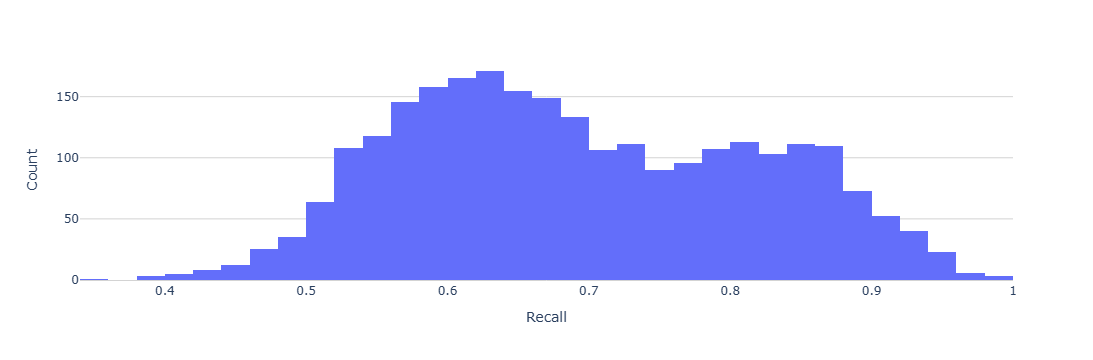

In [10]:
PX.hist(scores['recall'], xaxes = {'title': 'Recall'}, yaxes = {'title': 'Count'}, width=900)

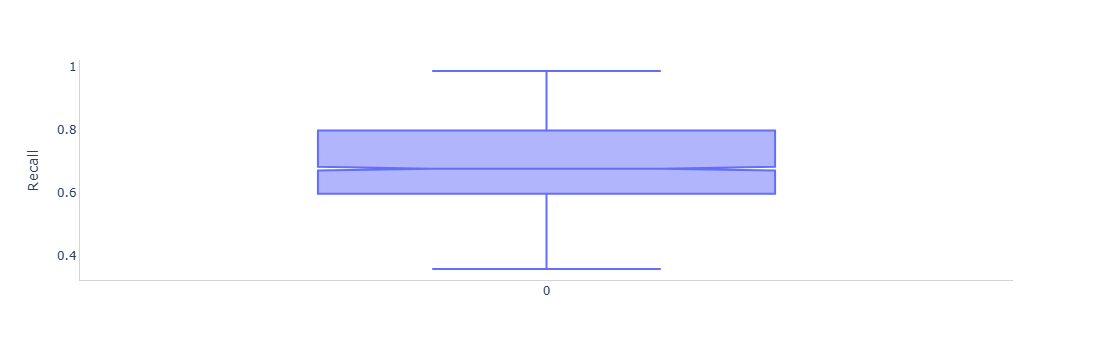

In [35]:
PX.box(scores['recall'], xaxes = {'title': ''}, yaxes = {'title': 'Recall'})

#### Precision Histogramm+Boxplot

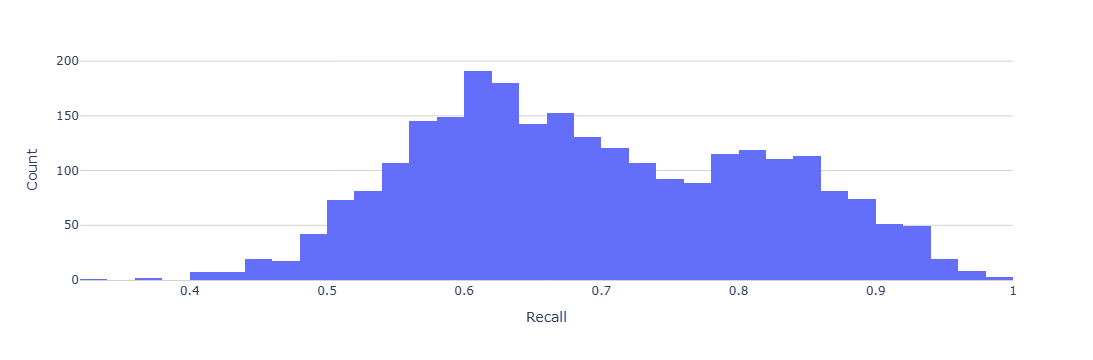

In [31]:
PX.hist(scores['precision'], xaxes = {'title': 'Recall'}, yaxes = {'title': 'Count'}, width=900)

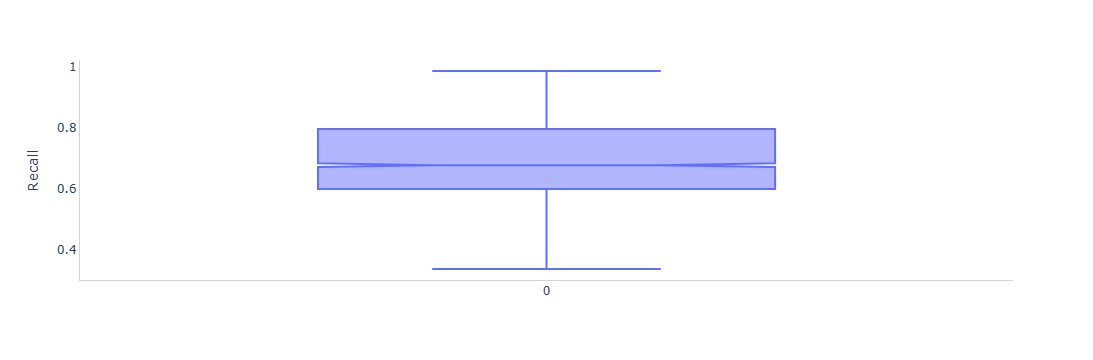

In [36]:
PX.box(scores['precision'], xaxes = {'title': ''}, yaxes = {'title': 'Recall'})

#### F1-Score Histogramm+Boxplot

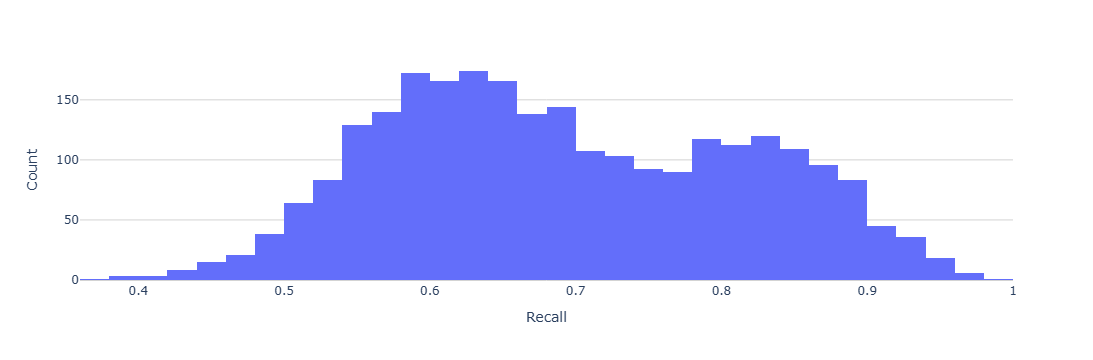

In [32]:
PX.hist(scores['f1_score'], xaxes = {'title': 'Recall'}, yaxes = {'title': 'Count'}, width=900)

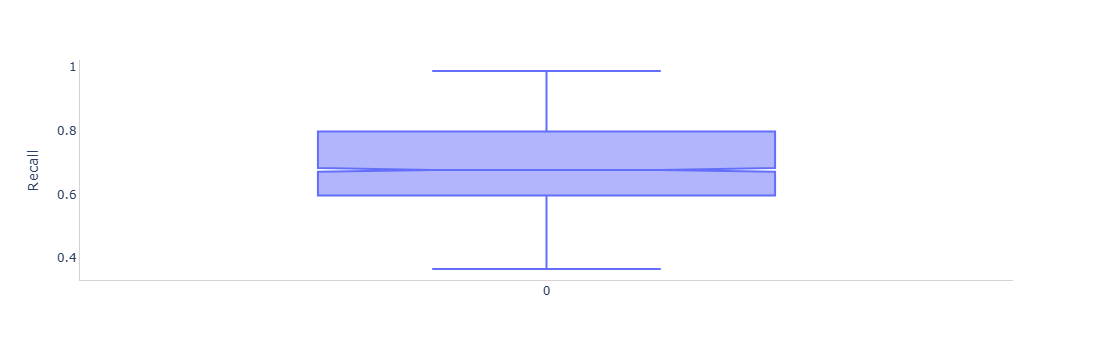

In [37]:
PX.box(scores['f1_score'], xaxes = {'title': ''}, yaxes = {'title': 'Recall'})

### Stats

Statistische Kennzahlen für Recall, Precision und F1-Score

In [59]:
print(f'mean: {scores["recall"].mean()}')
print(f'min: {scores["recall"].min()}')
print(f'max: {scores["recall"].max()}')
print(f'median: {np.median(scores["recall"])}')
print(f'std: {scores["recall"].std()}')
print(f'var: {scores["recall"].var()}')

mean: 0.6933652230638724
min: 0.3572937250137329
max: 0.9862551689147949
median: 0.6761347055435181
std: 0.1235827073757741
var: 0.015272685562326213


In [77]:
print(f'mean: {scores["precision"].mean()}')
print(f'min: {scores["precision"].min()}')
print(f'max: {scores["precision"].max()}')
print(f'median: {np.median(scores["precision"])}')
print(f'std: {scores["precision"].std()}')
print(f'var: {scores["precision"].var()}')

mean: 0.6934675726982263
min: 0.3379723131656647
max: 0.9862551689147949
median: 0.6778483688831329
std: 0.12284668421396959
var: 0.015091307822366767


In [9]:
print(f'mean: {scores["f1_score"].mean()}')
print(f'min: {scores["f1_score"].min()}')
print(f'max: {scores["f1_score"].max()}')
print(f'median: {np.median(scores["f1_score"])}')
print(f'std: {scores["f1_score"].std()}')
print(f'var: {scores["f1_score"].var()}')

mean: 0.6928669175708055
min: 0.36619183763227786
max: 0.9862551689147949
median: 0.6765842122344451
std: 0.12175678491473393
var: 0.01482471467277278


| Score | mean | min | max | median | std | var |
| - | - | - | - | - | - | - |
| **Referenz** | 0.5166153846153846 | 0.12 | 0.97 | 0.48 | 0.16995928854673878 | 0.028886159763313612 |
| **Recall** | 0.6933652230638724 | 0.3572937250137329 | 0.9862551689147949 | 0.6761347055435181 | 0.1235827073757741 | 0.015272685562326213 |
| **Precision** | 0.6934675726982263 | 0.3379723131656647 | 0.9862551689147949 | 0.6778483688831329 | 0.12284668421396959 | 0.015091307822366767 |
| **F1-Score** | 0.6928669175708055 | 0.36619183763227786 | 0.9862551689147949 | 0.6765842122344451 | 0.12175678491473393 | 0.01482471467277278 |

In [44]:
#Pearson correlation coefficient
#print(f'recall: {np.corrcoef(scores["recall"], list(dataset_semRel2024_split["label"]))}')
#print(f'precision: {np.corrcoef(scores["precision"], list(dataset_semRel2024_split["label"]))}')
#print(f'f1_score: {np.corrcoef(scores["f1_score"], list(dataset_semRel2024_split["label"]))}')

In [78]:
res = stats.pearsonr(scores['recall'], list(dataset_semRel2024_split['label']))
print(f'recall: {res.statistic}')
res = stats.pearsonr(scores['precision'], list(dataset_semRel2024_split['label']))
print(f'precision: {res.statistic}')
res = stats.pearsonr(scores['f1_score'], list(dataset_semRel2024_split['label']))
print(f'f1_score: {res.statistic}')

recall: 0.7486882257466436
precision: 0.751035806438148
f1_score: 0.7589821834048587


In [80]:
#x = np.array(scores['recall'])
#y = np.array(list(dataset_semRel2024_split['label']))

#((x - x.mean()) * (y - y.mean())).sum()/np.sqrt(((x - x.mean())**2).sum() * ((y - y.mean())**2).sum())

np.float64(0.7486882257466438)

In [82]:
#Spearman’s rank correlation coefficient
rho, p_value = stats.spearmanr(scores['recall'], list(dataset_semRel2024_split['label']))
print(f'recall: {rho}')
rho, p_value = stats.spearmanr(scores['precision'], list(dataset_semRel2024_split['label']))
print(f'precision: {rho}')
rho, p_value = stats.spearmanr(scores['f1_score'], list(dataset_semRel2024_split['label']))
print(f'f1_score: {rho}')

recall: 0.75003365852436
precision: 0.756130178110325
f1_score: 0.7620551311850854


In [81]:
#Kendall’s tau coefficient
#tau, p_value = stats.kendalltau(scores['recall'], list(dataset_semRel2024_split['label']))
#print(f'recall: {tau}')
#tau, p_value = stats.kendalltau(scores['precision'], list(dataset_semRel2024_split['label']))
#print(f'precision: {tau}')
#tau, p_value = stats.kendalltau(scores['f1_score'], list(dataset_semRel2024_split['label']))
#print(f'f1_score: {tau}')

Für den ermittelten BERTScore (Recall, Precision und F1-Score) der Text-Paare des Datensatzes wird die Korrelation zu dem durch die Annotatoren vergebenen Referenz-Score mit Hilfe des Pearson und Spearman’s rank correlation coefficient berechnet.

Pearson correlation coefficient

Der Pearson-Korrelationskoeffizient gibt die Stärke und Richtung des linearen Zusammenhangs zwischen zwei stetigen Variablen an und dessen mögliche Werte liegen im Bereich von -1 bis 1. Bei einem Wert von +1 besteht ein vollständig positiver linearer Zusammenhang und beide Variablen steigen gemeinsam an. Beträgt der Wert 0, liegt zwischen beiden Variablen kein linearer Zusammenhang vor. Steigt eine der Variablen an und sinkt der Andere demgegenüber, geht der Wert gegen -1 und es besteht ein negativer linearer Zusammenhang zwischen ihnen.

Wert im Bereich von 0.5 bis 1.0 können als starker positiver bzw. -0.5 bis -1.0 als starker negativer Zusammenhang interpretiert werden und niedrigere positive Werte bis 0.3 bzw. höhere negative Werte bis -0.3 als eher gering.

Die Berechnung des Korrelationskoeffizienten erfolgt wie folgt, wobei $m_x$ der Mittelwert des Vektors $x$ und $m_y$ der Mittelwert des Vektors $y$ ist.

$$r=\frac{\sum(x-m_x)(y-m_y)}{\sqrt{\sum(x-m_x)^2\sum(y-m_y)^2}}$$

Spearman’s rank correlation coefficient

Wie für den Pearson correlation coefficient liegen die möglichen Werte des Spearman’s rank correlation coefficient ebenso im Bereich von -1 bis 1 und werden analog interpretiert. Anders als die Pearson correlation, welche den linearen Zusammenhang zwischen zwei kontinuierlichen Variablen erfasst, bewertet die Spearman-Korrelation deren monotonen Zusammenhang, unabhängig davon, ob dieser linear ist oder nicht.

| Score | Pearson correlation | Spearman’s rank correlation |
| - | - | - |
| **Recall** | 0.7486882257466436 | 0.75003365852436 |
| **Precision** | 0.751035806438148 | 0.756130178110325 |
| **F1-Score** | 0.7589821834048587 | 0.7620551311850854 |

Zwischen dem berechneten BERTScore (F1-Score) und den Referenz-Scores besteht mit einem Wert von ca. 0.76 für den Pearson und Spearman’s rank correlation coefficient (Tabelle ...) ein starker positiver Zusammenhang und die mit Hilfe des BERTScore bestimmten Ähnlichkeiten richten sich relativ gut an den durch die menschlichen Annotatoren bewerteten Ähnlichkeiten der Satz-Paare aus.

## Test

Test zur Prüfung des Verhaltens der Methoden/Modelle unter verschiedenen Bedingungen wie ähnlicher und gegensätzlicher Formulierungen und unterschiedlicher Textlängen.

Generierung entsprechender Paare von Aussagen und Berechnung der Ähnlichkeit der Embedding-Vektoren für 4 Szenarien.

1. Ähnliche Aussagen+Wortanzahl
2. Ähnliche Aussagen mit unterschiedlicher Wortanzahl
3. Gegensätzliche Aussage
4. Gegensätzliche Aussage mit gemeinsamen Wörtern

Aufgrund der geringen Anzahl an Beispielen ist der Test nicht repräsentativ.

In [60]:
# Mock Test
# Test der Berechnung der Ähnlichkeit
# Beispiel-Aussage sowie ähnliche und gegensätzliche Formulierung durch LLM generieren

# Ähnliche Aussagen
#
#Erstellung einer Aussage und einer alternativen Formulierung der selben Aussage
#
#Prompt:
#Create a statement consisting of 2–3 sentences and output it alongside an alternative phrasing of the same statement. The sequence of sentences in the alternative phrasing should not follow the same order as the sentences in the original statement.
#
#Modell: Gemini 3 3.5 Flash
#
#Original Statement:
#Studying a new language opens doors to understanding different cultures more deeply. It also sharpens your cognitive skills and improves memory over time. For these reasons, language learning is a highly rewarding pursuit.
#
#Alternative Phrasing:
#Language learning is a highly rewarding pursuit for a couple of key reasons. Over time, it sharpens your cognitive skills and improves memory. Additionally, studying a new language opens doors to understanding different cultures more deeply.

statement_original = 'Studying a new language opens doors to understanding different cultures more deeply. It also sharpens your cognitive skills and improves memory over time. For these reasons, language learning is a highly rewarding pursuit.'
statement_similiar = 'Language learning is a highly rewarding pursuit for a couple of key reasons. Over time, it sharpens your cognitive skills and improves memory. Additionally, studying a new language opens doors to understanding different cultures more deeply.'

precision, recall = scorer.score(statement_similiar, statement_original)

f1_score = 2 * precision * recall / (precision + recall)

# Dot Product zwischen Sätzen der original und alternativen Aussage berechnen und Confusion-Matrix erzeugen
# Über alle Sätze der Originalaussage iterieren (Zeilen)
# Für jeden Satz der Originalaussage
# Über alle Sätze der alternativen Aussage iterieren (einzelne Werte)
# Dot Product für Satz aus Originalaussage und Satz aus alternativer Aussage berechnen

#cm = []
#cm_row_max = []
#
#for j in range(len(s1)):
#    cm_row = []
#    for k in range(len(s2)):
#        # Dot Product berechnen
#        cm_row.append(np.dot(s1[j].embedding, s2[k].embedding))
#    cm_row_max.append(cm_row[np.argmax(cm_row)])
#    cm.append(cm_row

#cm, cm_row_max = bert_score(responses_statement_alternative.data, responses_statement_original.data)
#print(f'cm_row_max: {cm_row_max}')
#displayConfusionMatrix(cm, xaxes={'labels': df_statement_alternative_split.iloc[0][:-1], 'title': 'alternative statement'}, yaxes={'labels': df_statement_original_split.iloc[0][:-1], 'title': 'original statement'})

# Gegenüberstellung der Original- und alternativen Aussage
# Nested List Comprehension
#cm = [[np.dot(responses_statement_original.data[j].embedding, responses_statement_alternative.data[k].embedding) for k in range(len(responses_statement_alternative.data))] for j in range(len(responses_statement_original.data))]

Precision: 0.9239
Recall: 0.9452
F1-Score: 0.9344


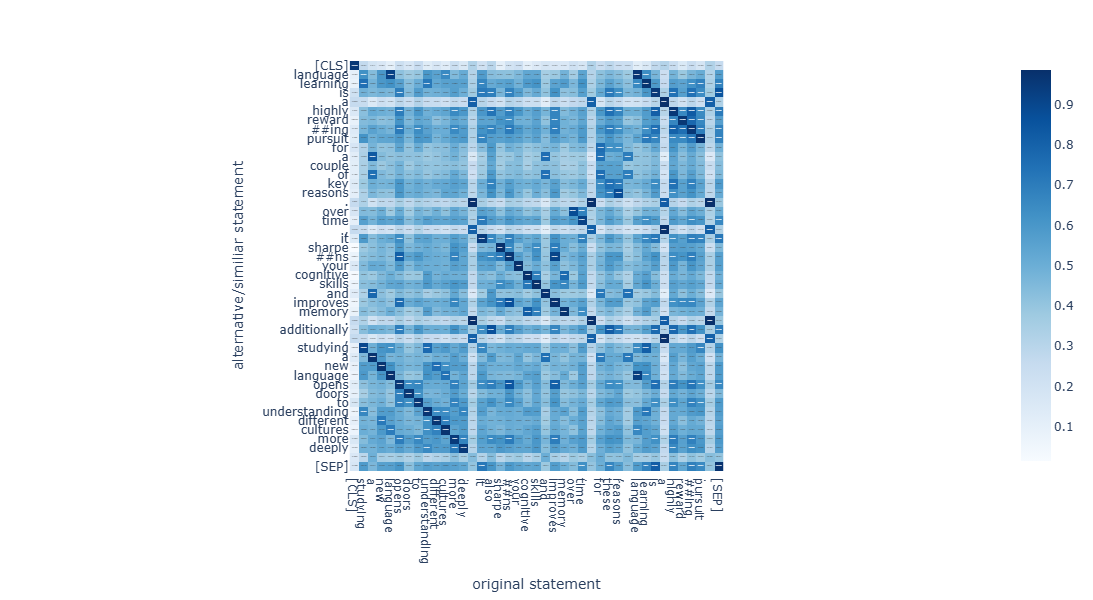

In [61]:
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f'F1-Score: {f1_score:.4f}')

PX.displayConfusionMatrix(
    scorer.similarity(statement_similiar, statement_original).to('cpu'), 
    xaxes={'labels': scorer.encode_decode(statement_original), 'title': 'original statement'}, #[1:-1]
    yaxes={'labels': scorer.encode_decode(statement_similiar), 'title': 'alternative/similiar statement'}
)

In [75]:
# Ähnliche Aussagen mit unterschiedlicher Anzahl Wörter
#
#Erstellung einer Aussage und einer alternativen Formulierung der selben Aussage mit unterschiedlicher Anazhl an Wörtern
#
#Prompt:
#Create a statement consisting of 2–3 sentences and output it alongside an alternative phrasing of the same statement. The two statements should contain a different number of words.
#
#Modell: Gemini 3 3.5 Flash
#
#Original Statement:
#Learning a new language can be a challenging but deeply rewarding experience. It opens up doors to new cultures and allows you to connect with people from all over the world. Dedicated practice is the ultimate key to achieving fluency.
#
#Alternative Phrasing:
#Mastering a foreign language is difficult yet incredibly fulfilling because it unveils diverse cultures and connects you globally. Consistent practice is essential for fluency.

#Modell: GPT-5.5 Instant
#
#Statement:
#The project is progressing steadily, and the team expects to finish on schedule. Everyone is reviewing the final details carefully.
#
#Alternative phrasing:
#Work on the project continues at a consistent pace, with completion still expected by the planned deadline, while every team member carefully checks the remaining details.

statement_similiar_word_count_different_1 = 'Learning a new language can be a challenging but deeply rewarding experience. It opens up doors to new cultures and allows you to connect with people from all over the world. Dedicated practice is the ultimate key to achieving fluency.'
statement_similiar_word_count_different_2 = 'Mastering a foreign language is difficult yet incredibly fulfilling because it unveils diverse cultures and connects you globally. Consistent practice is essential for fluency.'

#statement_similiar_word_count_different_1 = 'The project is progressing steadily, and the team expects to finish on schedule. Everyone is reviewing the final details carefully.'
#statement_similiar_word_count_different_2 = 'Work on the project continues at a consistent pace, with completion still expected by the planned deadline, while every team member carefully checks the remaining details.'

precision, recall = scorer.score(statement_similiar_word_count_different_2, statement_similiar_word_count_different_1)

f1_score = 2 * precision * recall / (precision + recall)

Precision: 0.8410
Recall: 0.8211
F1-Score: 0.8309


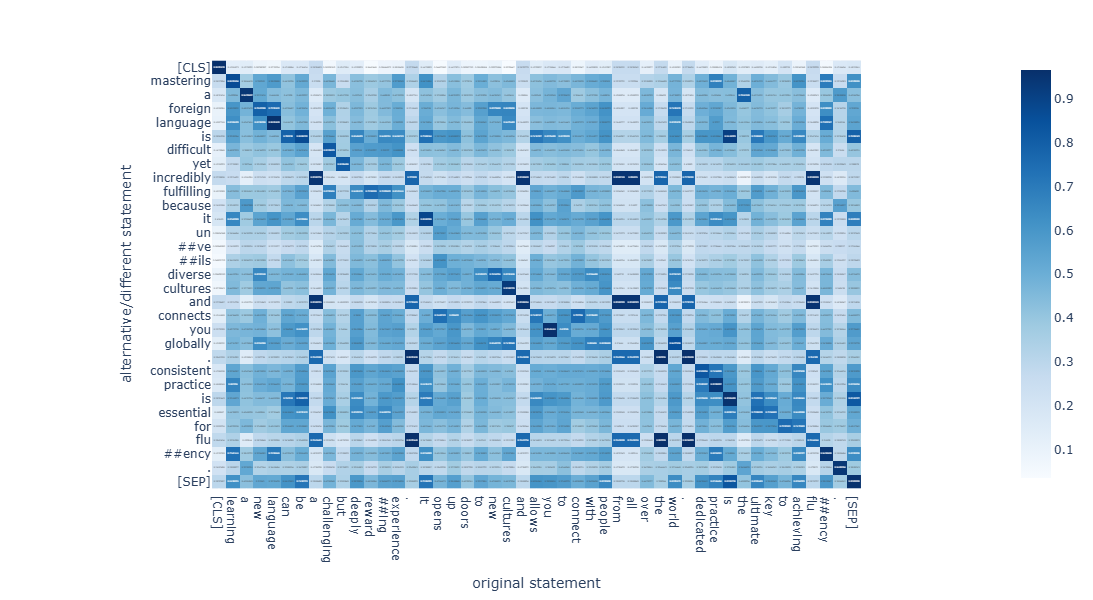

In [76]:
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f'F1-Score: {f1_score:.4f}')

PX.displayConfusionMatrix(
    scorer.similarity(statement_similiar_word_count_different_2, statement_similiar_word_count_different_1).to('cpu'), 
    xaxes={'labels': scorer.encode_decode(statement_similiar_word_count_different_1), 'title': 'original statement'}, 
    yaxes={'labels': scorer.encode_decode(statement_similiar_word_count_different_2), 'title': 'alternative/different statement'}
)

In [62]:
# Gegensätzliche Aussagen
#
# Erstellung einer Aussage und einer gegensätzlichen Aussage
#
#Prompt:
#Create a statement consisting of 2–3 sentences and output it alongside a statement that is either contradictory or thematically different.
#
#Modell: Gemini 3 3.5 Flash
#
#Statement 1:
#Exploring deep space requires advanced propulsion technologies that can withstand extreme cosmic environments. Over the next few decades, scientists hope to launch autonomous probes to our neighboring star systems. These missions could fundamentally reshape our understanding of the universe.
#
#Statement 2 (Thematically Different):
#Baking the perfect loaf of sourdough bread relies heavily on maintaining a healthy, active wild yeast starter. Simple variables like ambient room temperature and water quality can drastically alter the final texture and flavor of the crust.

statement_original = 'Exploring deep space requires advanced propulsion technologies that can withstand extreme cosmic environments. Over the next few decades, scientists hope to launch autonomous probes to our neighboring star systems. These missions could fundamentally reshape our understanding of the universe.'
statement_different = 'Baking the perfect loaf of sourdough bread relies heavily on maintaining a healthy, active wild yeast starter. Simple variables like ambient room temperature and water quality can drastically alter the final texture and flavor of the crust.'

precision, recall = scorer.score(statement_different, statement_original)

f1_score = 2 * precision * recall / (precision + recall)

Precision: 0.5834
Recall: 0.5690
F1-Score: 0.5761


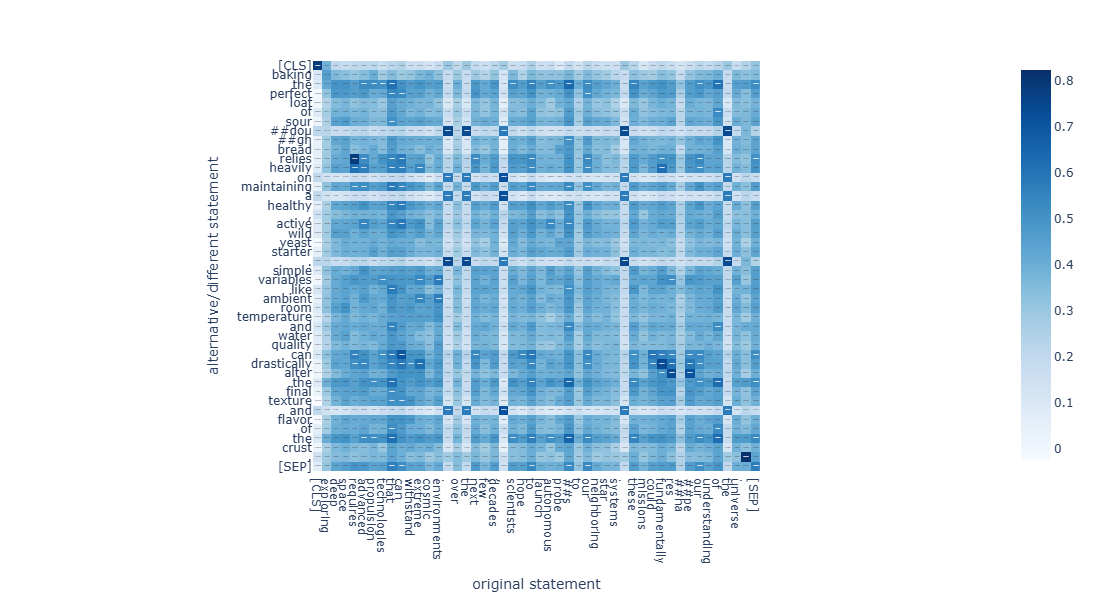

In [64]:
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f'F1-Score: {f1_score:.4f}')

PX.displayConfusionMatrix(
    scorer.similarity(statement_different, statement_original).to('cpu'), 
    xaxes={'labels': scorer.encode_decode(statement_original), 'title': 'original statement'}, 
    yaxes={'labels': scorer.encode_decode(statement_different), 'title': 'alternative/different statement'}
)

In [71]:
# Gegensätzliche Aussage mit gemeinsamen Worten
#
#Zwei gegensätzliche Aussagen sollen mehrere gemeinsame Worte teilen
#
#Prompt:
#Create a statement consisting of 2–3 sentences and output it alongside a statement on a different topic. Both statements should share several words.
#
#Modell: Gemini 3 3.5 Flash
#
#Statement 1:
#The bright stars in the night sky always inspire wonder. Astronomers study these distant worlds to learn how the universe was formed.
#
#Statement 2:
#Dedicated teachers in the school inspire students every day. Young minds study hard night and day under a bright future.

statement_different_shared_words_1 = 'The bright stars in the night sky always inspire wonder. Astronomers study these distant worlds to learn how the universe was formed.'
statement_different_shared_words_2 = 'Dedicated teachers in the school inspire students every day. Young minds study hard night and day under a bright future.'

precision, recall = scorer.score(statement_different_shared_words_2, statement_different_shared_words_1)

f1_score = 2 * precision * recall / (precision + recall)

In [73]:
# Gegensätzliche Aussage mit gemeinsamen Worten
#
#Zwei gegensätzliche Aussagen sollen möglichst viele Worte teilen
#
#Prompt:
#Create a statement consisting of 2–3 sentences and output it alongside a statement on a different topic. Both statements should share as many words as possible.
#
#Modell: Gemini 3 3.5 Flash
#
#Statement 1:
#The deep space telescope captured a brilliant new star shining brightly in the distant galaxy. This remarkable discovery completely changed how the brilliant scientists viewed the universe.
#
#Statement 1:
#The deep ocean resort captured a brilliant new market shining brightly in the distant region. This remarkable discovery completely changed how the brilliant directors viewed the luxury industry.

statement_different_shared_words_1 = 'The deep space telescope captured a brilliant new star shining brightly in the distant galaxy. This remarkable discovery completely changed how the brilliant scientists viewed the universe.'
statement_different_shared_words_2 = 'The deep ocean resort captured a brilliant new market shining brightly in the distant region. This remarkable discovery completely changed how the brilliant directors viewed the luxury industry.'

precision, recall = scorer.score(statement_different_shared_words_2, statement_different_shared_words_1)

f1_score = 2 * precision * recall / (precision + recall)

Precision: 0.7726
Recall: 0.7749
F1-Score: 0.7737


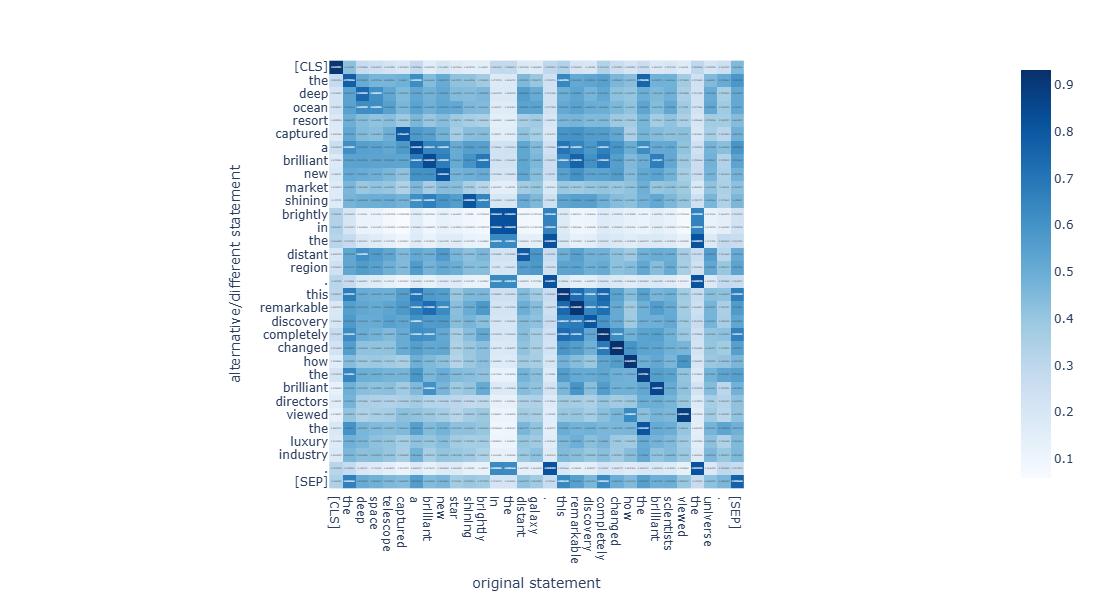

In [74]:
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f'F1-Score: {f1_score:.4f}')

PX.displayConfusionMatrix(
    scorer.similarity(statement_different_shared_words_2, statement_different_shared_words_1).to('cpu'), 
    xaxes={'labels': scorer.encode_decode(statement_different_shared_words_1), 'title': 'original statement'}, 
    yaxes={'labels': scorer.encode_decode(statement_different_shared_words_2), 'title': 'alternative/different statement'}
)

| Eingabe | Recall | Precision | F1-Score |
| - | - | - | - |
| Ähnliche Aussagen+Wortanzahl | 0.9452 | 0.9239 | 0.9344 |
| Ähnliche Aussagen mit unterschiedlicher Wortanzahl | 0.8211 | 0.8410 | 0.8309 |
| Gegensätzliche Aussage | 0.5690 | 0.5834 | 0.5761 |
| Gegensätzliche Aussage mit gemeinsamen Worten | 0.7749 | 0.7726 | 0.7737 |

Für die durch das LLM generierten ähnlichen Aussagen mit ähnlicher Wortzahl wurde ein mit 0.9344 entsprechend hoher BERTScore (F1-Score) berechnet, bei unterschiedlicher Wortanzahl fällt dieser auf 0.8309 ab (Tabelle ). Mit einem Wert von 0.5761 wurde für die gegensätzlichen Aussagen ein hoher F1-Score berechnet und dieser steigt beim Vorhandensein ähnlicher Wörter in beiden Texten auf 0.7737 stark an. Die berechnete Ähnlichkeit scheint, unabhängig vom Zusammenhang der Aussagen, in gewissem Maße von der Gesamtzahl und Zahl der gemeinsamen Wörter abzuhängen.